# Análisis Exploratorio: Tráfico Madrid 2022

Este notebook procesa y analiza los datos de aforamiento de tráfico permanente de Madrid durante 2022. Los datos en crudo consisten en 12 archivos Excel mensuales almacenados en la carpeta `2022_aforoTrafico/Meses`, que contienen mediciones de intensidad vehicular registradas por estaciones de control distribuidas por la ciudad.

**Fuente:** [Portal de Datos Abiertos del Ayuntamiento de Madrid](https://datos.madrid.es/)

**Dataset:** [Datos del tráfico desde 2013](https://datos.madrid.es/portal/site/egob/menuitem.c05c1f754a33a9fbe4b2e4b284f1a5a0/?vgnextoid=fabbf3e1de124610VgnVCM2000001f4a900aRCRD&vgnextchannel=374512b9ace9f310VgnVCM100000171f5a0aRCRD&vgnextfmt=default)

El objetivo es preparar estos datos para su integración con información de BiciMad, datos meteorológicos y calendario laboral, permitiendo análisis integrados del ecosistema de movilidad madrileño en 2022.

### 0. Requirements

In [2]:
import os # Para manejo de rutas
import glob # Para manejo de ficheros
import pandas as pd # Para manejo de dataframes
import numpy as np # Para operaciones numéricas
import matplotlib.pyplot as plt # Para gráficos
from pathlib import Path # Para manejo de rutas
import openpyxl # Para leer archivos Excel

## 1. Carga de datos

En la carpeta `2022_aforoTrafico/Meses` tenemos 12 archivos Excel que contienen los registros de tráfico mes a mes. Nuestro objetivo en esta sección es concatenar todos ellos en un único DataFrame que unifique todas las mediciones de tráfico registradas en 2022. 

Los datos provienen de estaciones de aforamiento permanente distribuidas por Madrid que registran el volumen de tráfico las 24 horas del día, los 365 días del año.

In [3]:
DATA_DIR = '2022_aforoTrafico/Meses'
files = sorted(glob.glob(os.path.join(DATA_DIR, 'DatosEstaciones*.xlsx')))
print('Archivos Excel encontrados:', len(files))
files

Archivos Excel encontrados: 12


['2022_aforoTrafico/Meses\\DatosEstacionesAbril2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesAgosto2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesDiciembre2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesEnero2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesFebrero2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesJulio2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesJunio2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesMarzo2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesMayo2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesNoviembre2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesOctubre2022.xlsx',
 '2022_aforoTrafico/Meses\\DatosEstacionesSeptiembre2022.xlsx']

In [4]:
# Verificar que todos los archivos tienen las mismas columnas
print("Verificando consistencia de columnas:")
columnas_primer_archivo = set(pd.read_excel(files[0], nrows=0, sheet_name='DATOS').columns)
todos_iguales = True

for ruta in files[1:]:
    columnas_archivo = set(pd.read_excel(ruta, nrows=0, sheet_name='DATOS').columns)
    diferencia = columnas_archivo - columnas_primer_archivo
    if diferencia:
        print(f"{Path(ruta).name}: {diferencia}")
        todos_iguales = False

print("Todos los archivos tienen las mismas columnas" if todos_iguales else "Hay diferencias en las columnas")

Verificando consistencia de columnas:
Todos los archivos tienen las mismas columnas
Todos los archivos tienen las mismas columnas


In [5]:
# Cargar todos los archivos mensuales
dfs_mensuales = []

for ruta in files:
    df = pd.read_excel(ruta, sheet_name='DATOS')
    dfs_mensuales.append(df)

print(f"\nArchivos cargados exitosamente: {len(dfs_mensuales)}")


Archivos cargados exitosamente: 12


In [6]:
# Concatenar todos los meses en un único DataFrame
df_trafico2022 = pd.concat(dfs_mensuales, ignore_index=True)
print(f'Dimensiones del dataset unificado: {df_trafico2022.shape}')
print(f"Registros totales: {len(df_trafico2022):,}")

Dimensiones del dataset unificado: (86140, 15)
Registros totales: 86,140


## 2. Comprension General de los datos

In [7]:
df_trafico2022.head(10)

,FDIA,FEST,FSEN,HOR1,HOR2,HOR3,HOR4,HOR5,HOR6,HOR7,HOR8,HOR9,HOR10,HOR11,HOR12
0,2022-04-01 00:00:00,ES01,1-,518,308,215,180,267,705,1890,2326,2031,1757,1900,1938
1,2022-04-01 00:00:00,ES01,1=,2161,2619,2209,1816,1754,1751,1733,1835,1689,1251,1037,1239
2,2022-04-01 00:00:00,ES01,2-,413,309,261,212,187,356,712,1316,1438,1201,1309,1321
3,2022-04-01 00:00:00,ES01,2=,1329,1315,1348,1319,1373,1307,1356,1387,1218,907,761,780
4,2022-04-01 00:00:00,ES02,1-,285,256,162,143,98,107,161,302,550,620,530,547
5,2022-04-01 00:00:00,ES02,1=,558,529,482,461,482,499,577,614,536,552,487,436
6,2022-04-01 00:00:00,ES02,2-,671,490,371,252,245,289,587,1137,1305,1244,1128,1151
7,2022-04-01 00:00:00,ES02,2=,1208,1243,1286,1267,1172,1103,1117,1132,1092,1143,1155,983
8,2022-04-01 00:00:00,ES03,1-,400,220,137,111,118,144,449,1952,2557,2175,1711,1574
9,2022-04-01 00:00:00,ES03,1=,1628,1502,1870,2194,1970,1612,1765,1705,1588,1252,251,674


### 2.1 Estructura del Dataset

**Campos principales:**
- **FDIA:** Fecha en la que se tomó el dato
- **FEST:** Código de estación (60 estaciones de medición permanente)
- **FSEN:** Sentido del tráfico con codificación temporal:
  - **1-** Sentido 1, datos de 1:00 a 12:00
  - **1=** Sentido 1, datos de 13:00 a 24:00  
  - **2-** Sentido 2, datos de 1:00 a 12:00
  - **2=** Sentido 2, datos de 13:00 a 24:00
- **HOR1-HOR12:** Intensidad vehicular por franjas horarias (períodos de 2 horas cada uno)

En resumen, hay 4 filas por día y estación, una para cada sentido y franja horaria. Así, cada día tiene 60x4 filas.

### 2.2 Tipado de datos

In [8]:
# Verificar tipos de datos actuales
print("Tipos de datos actuales:")
print(df_trafico2022.dtypes)
print("\n" + "="*50)


Tipos de datos actuales:
FDIA     object
FEST     object
FSEN     object
HOR1      int64
HOR2      int64
HOR3      int64
HOR4      int64
HOR5      int64
HOR6      int64
HOR7      int64
HOR8      int64
HOR9      int64
HOR10     int64
HOR11     int64
HOR12     int64
dtype: object



In [9]:
# Convertir tipos de datos
df_trafico2022['FDIA'] = pd.to_datetime(df_trafico2022['FDIA'])
df_trafico2022['FEST'] = df_trafico2022['FEST'].astype('category')
df_trafico2022['FSEN'] = df_trafico2022['FSEN'].astype('category')

print("Tipado aplicado:")
print(df_trafico2022.dtypes)

Tipado aplicado:
FDIA     datetime64[ns]
FEST           category
FSEN           category
HOR1              int64
HOR2              int64
HOR3              int64
HOR4              int64
HOR5              int64
HOR6              int64
HOR7              int64
HOR8              int64
HOR9              int64
HOR10             int64
HOR11             int64
HOR12             int64
dtype: object


# 3. Limpieza


### 3.1 Valores Faltantes

In [10]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
valores_faltantes = df_trafico2022.isnull().sum()
print(valores_faltantes)

Valores faltantes por columna:
FDIA     0
FEST     0
FSEN     0
HOR1     0
HOR2     0
HOR3     0
HOR4     0
HOR5     0
HOR6     0
HOR7     0
HOR8     0
HOR9     0
HOR10    0
HOR11    0
HOR12    0
dtype: int64


### 3.2 Valores Duplicados

En el análisis de duplicados, como Pandas solo hace un recuento de duplicados en cuanto a columnas numéricas, encuntra 198 duplicados. Sin embargo, al mostrar ejemplos, vemos que se deeben a filas en las que todos los registros fueron 0, pero no son duplicadso ya que no se corresponden a la misma estación o sentido (columnas FEST y FSEN).

In [11]:
# Verificar duplicados completos
duplicados_completos = df_trafico2022.duplicated().sum()
print(f"Registros con valores idénticos: {duplicados_completos}")

print("Primeras 10 filas duplicadas (incluyendo originales):")
print(df_trafico2022[df_trafico2022.duplicated()].head(10))
print("(Filas con mismos valores de tráfico pero diferentes estaciones/sentidos)")


Registros con valores idénticos: 198
Primeras 10 filas duplicadas (incluyendo originales):
            FDIA  FEST FSEN  HOR1  HOR2  HOR3  HOR4  HOR5  HOR6  HOR7  HOR8  \
15138 2022-04-12  ES09   2-     0     0     0     0     0     0     0     0   
15139 2022-04-12  ES09   2=     0     0     0     0     0     0     0     0   
15140 2022-04-12  ES10   1-     0     0     0     0     0     0     0     0   
15141 2022-04-12  ES10   1=     0     0     0     0     0     0     0     0   
15150 2022-04-12  ES12   2-     0     0     0     0     0     0     0     0   
15151 2022-04-12  ES12   2=     0     0     0     0     0     0     0     0   
15170 2022-04-12  ES17   2-     0     0     0     0     0     0     0     0   
15171 2022-04-12  ES17   2=     0     0     0     0     0     0     0     0   
15178 2022-04-12  ES19   2-     0     0     0     0     0     0     0     0   
15179 2022-04-12  ES19   2=     0     0     0     0     0     0     0     0   

       HOR9  HOR10  HOR11  HOR12  
1513

### 3.3 Anomalías

#### **En las estaciones y sentidos:**

In [12]:
# Verificar distribución de estaciones y sentidos
print("Verificando uniformidad en la distribución:")

# Verificar que todas las estaciones aparecen el mismo número de veces
conteo_estaciones = df_trafico2022['FEST'].value_counts()
print(f"Estaciones únicas: {len(conteo_estaciones)}")
print(f"Registros por estación - Min: {conteo_estaciones.min()}, Max: {conteo_estaciones.max()}")

# Verificar que todos los sentidos aparecen el mismo número de veces  
conteo_sentidos = df_trafico2022['FSEN'].value_counts()
print(f"Sentidos únicos: {len(conteo_sentidos)}")
print(f"Registros por sentido - Min: {conteo_sentidos.min()}, Max: {conteo_sentidos.max()}")

Verificando uniformidad en la distribución:
Estaciones únicas: 59
Registros por estación - Min: 1460, Max: 1460
Sentidos únicos: 4
Registros por sentido - Min: 21535, Max: 21535


+ Los resultados confirman que no hay problemas en la distribución de los datos. Todas las estaciones aparecen con la misma frecuencia (1,464 registros cada una) y los 4 sentidos están equilibrados (21,960 registros por sentido), lo que indica una estructura de datos consistente sin anomalías.

#### **En el recuento de afluencia de tráfico:**

Los gráficos de violín revelan que la mayoría de mediciones de intensidad vehicular se concentran en valores bajos, con distribuciones asimétricas típicas del tráfico urbano:

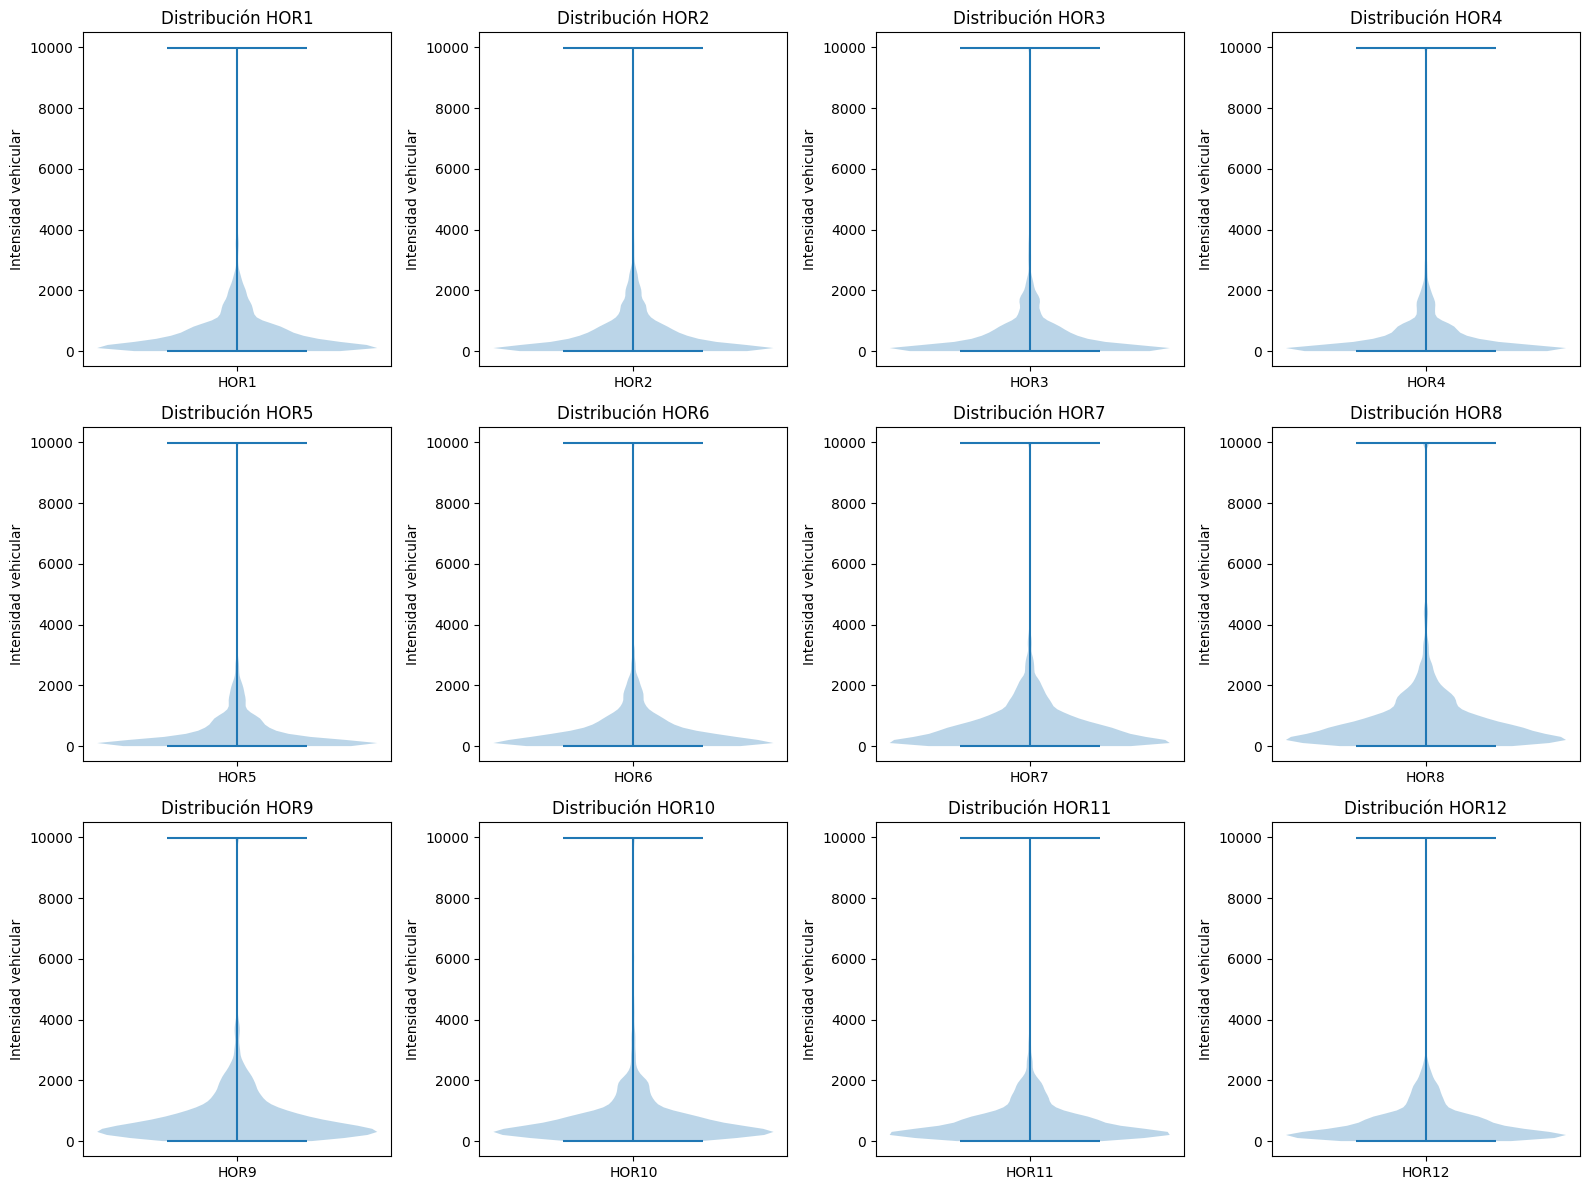

In [13]:
# Gráficos de violín para las columnas de intensidad horaria
columnas_intensidad = [f'HOR{i}' for i in range(1, 13)]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, columna in enumerate(columnas_intensidad):
    axes[i].violinplot(df_trafico2022[columna].dropna(), positions=[1])
    axes[i].set_title(f'Distribución {columna}')
    axes[i].set_ylabel('Intensidad vehicular')
    axes[i].set_xticks([1])
    axes[i].set_xticklabels([columna])

plt.tight_layout()
plt.show()

**Análisis de valores altos:** Se observan valores extremos cerca de 10.000 vehículos/hora en todas las franjas horarias. Los siguientes gráficos muestran únicamente la distribución de valores superiores a 3.000 para examinar estos casos:

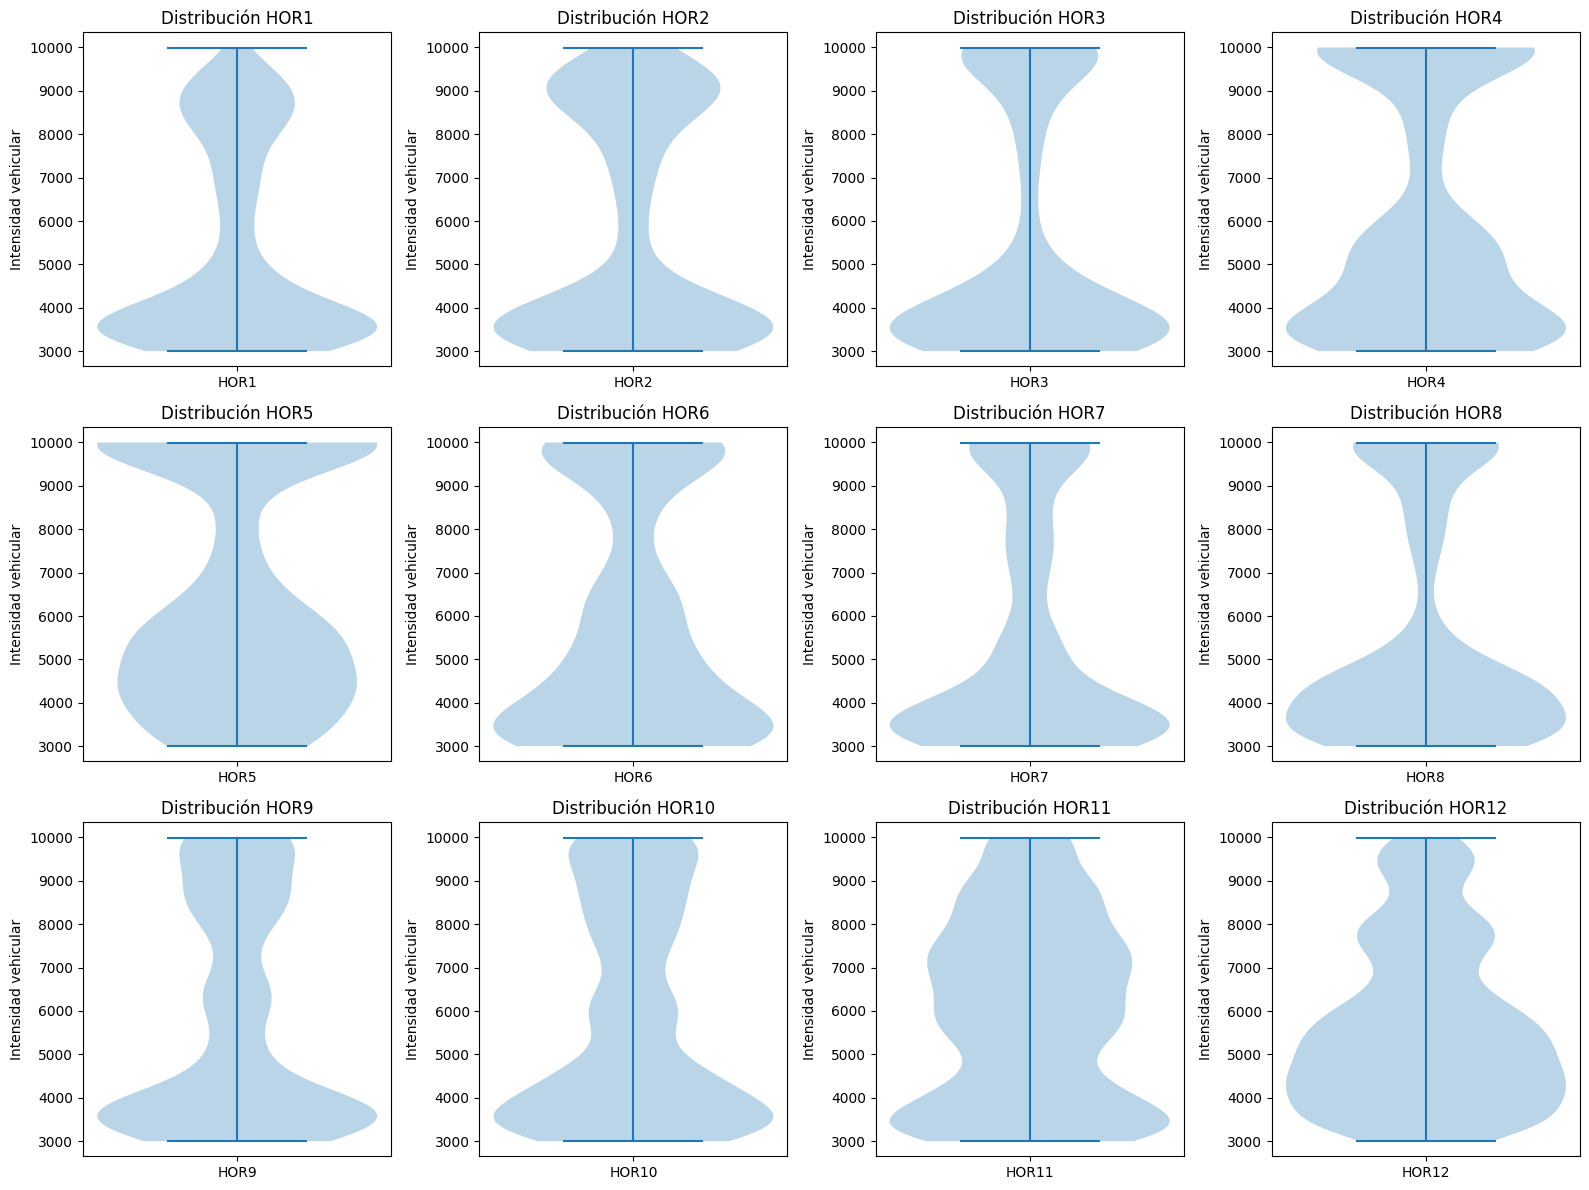

In [14]:
# Gráficos de violín para las columnas de intensidad horaria (solo valores > 3000)
columnas_intensidad = [f'HOR{i}' for i in range(1, 13)]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, columna in enumerate(columnas_intensidad):
    datos_filtrados = df_trafico2022[df_trafico2022[columna] > 3000][columna].dropna()
    if not datos_filtrados.empty:  # Verificar que hay datos para graficar
        axes[i].violinplot(datos_filtrados, positions=[1])
        axes[i].set_title(f'Distribución {columna}')
        axes[i].set_ylabel('Intensidad vehicular')
        axes[i].set_xticks([1])
        axes[i].set_xticklabels([columna])
    else:
        axes[i].set_visible(False)  # Ocultar el gráfico si no hay datos

plt.tight_layout()
plt.show()

### Análisis de Percentiles

Los percentiles proporcionan una visión precisa de la distribución de intensidad vehicular y la frecuencia de valores extremos:

In [ ]:
# Análisis de percentiles para las columnas de intensidad horaria
columnas_intensidad = [f'HOR{i}' for i in range(1, 13)]

df_limpio = df_trafico2022.copy()

# Calcular percentiles de 10 en 10
percentiles = [0.9, 0.95, 0.975, 0.99]
descripcion_percentiles = df_limpio[columnas_intensidad].describe(percentiles=percentiles)

print("Estadísticas descriptivas con percentiles (valores 9999 excluidos):")
print(descripcion_percentiles.round(1))

Estadísticas descriptivas con percentiles (valores 9999 excluidos):
          HOR1     HOR2     HOR3     HOR4     HOR5     HOR6     HOR7     HOR8  \
count  86135.0  86119.0  85858.0  85693.0  85775.0  85948.0  85866.0  85674.0   
mean     649.8    623.2    555.6    507.3    504.0    583.1    711.5    825.9   
std      968.8    989.3    910.3    828.2    782.3    856.1    888.8    989.1   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%      357.0    309.0    255.0    221.0    222.0    324.0    469.0    554.0   
90%     1558.0   1565.0   1472.0   1359.0   1343.0   1425.0   1664.0   1830.0   
95%     2073.3   2137.0   1941.0   1856.0   1858.0   1953.0   2166.0   2423.3   
97.5%   2658.0   2646.0   2651.1   2466.7   2313.0   2460.0   2780.0   3222.2   
99%     4441.6   4028.3   3871.9   3742.1   3254.8   3708.5   3727.2   4532.3   
max     9948.0   9997.0   9996.0   9990.0   9996.0   9998.0   9991.0   9998.0   

          HOR9    HOR10    HOR11    HOR1

#### Conclusión

Tras este análisis, determinamos que las columnas no presentan datos anómalos que se deban a errores en la recogida de datos o irrregularidades que afecten a la manera en la que los datos describen la realidad. Las razones de esta decision son:
+ Las distribucioned de valores mayores a 3.000 que vimos en los graficos de violin no muestran una tendencia general a lo largo de las 12 columnas, por lo que no estamos ante un error sistemático. Además, las distribuciones son bastante realistas. Muhcas de ellas muestran un pico entre los 9000 y 10000 , lo que podría estar indicando que los detectores o los datos tienen un máximo en 1.000 que no permite registrar valores mayores que esos.
+ Con los percentiles vemos que el 99% de los datos son menores que un umbral situado entre 3254 y 6937 en todas las columnas, por tanto los datos anomalamente altos son muy pocos y su efecto no es tan critico.

### 3.4 Comprobacion de cobertura diaria

In [ ]:
# Cobertura diaria rápida en df_trafico2022
rango = pd.date_range('2022-01-01','2022-12-31', freq='D').date
presentes = pd.to_datetime(df_trafico2022['FDIA']).dt.date.unique()
faltantes = sorted(set(rango) - set(presentes))
print(f"Días presentes: {len(presentes)} | Faltantes: {len(faltantes)}")
print(f"Primeros faltantes: {faltantes[:5]}")

Comprobamos en el dataset acumulado hasta este punto (`df_trafico2022`) que no hay registros para todos los días de 2022.

Se observa un intervalo de 11 días sin datos: del 2022-12-01 al 2022-12-11.

# 4. Transformacion

Objetivos de la seccion: 

+ Añadir los nombres de las estacioens, que estan en cualqueira de los archivos de datos mensuales pero e nla hoja 'ESTACIONES' con un ID, que en la tabla principal encontramos en la columna FEST (con una codificacion ESXX por lo que hay que eliminar el ES)

+ Preparar el dataset para un analisis hora a hora. Cada estacion por hora de un dia sera una fila del dataset. 

In [16]:
df_trafico2022.head()

,FDIA,FEST,FSEN,HOR1,HOR2,HOR3,HOR4,HOR5,HOR6,HOR7,HOR8,HOR9,HOR10,HOR11,HOR12
0,2022-04-01,ES01,1-,518,308,215,180,267,705,1890,2326,2031,1757,1900,1938
1,2022-04-01,ES01,1=,2161,2619,2209,1816,1754,1751,1733,1835,1689,1251,1037,1239
2,2022-04-01,ES01,2-,413,309,261,212,187,356,712,1316,1438,1201,1309,1321
3,2022-04-01,ES01,2=,1329,1315,1348,1319,1373,1307,1356,1387,1218,907,761,780
4,2022-04-01,ES02,1-,285,256,162,143,98,107,161,302,550,620,530,547


In [17]:
# Cargar información de las 60 estaciones
df_estaciones = pd.read_excel(files[0], sheet_name='ESTACIONES', usecols=['Nº', 'ESTACIÓN'], index_col='Nº')
print(f"Total de estaciones: {len(df_estaciones)}")
df_estaciones

Total de estaciones: 60


,ESTACIÓN
Nº,
1,Paseo de la Castellana
2,Calle Princesa
3,Calle Doctor Esquerdo
4,Paseo de San Franciso de Sales
5,Paseo de Santa María de la Cabeza
6,Calle Arturo Soria
7,Avenida de Portugal
8,Calle Gran Vía
9,Calle Atocha


### 4.1 Añadir nombres de estaciones

Reemplazaremos la columna `FEST` (códigos ES01, ES02...) por los nombres descriptivos de las estaciones.

In [18]:
# Extraer número de estación eliminando prefijo 'ES'
df_trafico2022['id_estacion'] = df_trafico2022['FEST'].str.replace('ES', '').astype(int)

# Verificar la conversión
print("Conversión de códigos:")
print(df_trafico2022[['FEST', 'id_estacion']].head())

# Unir con nombres de estaciones
df_trafico2022 = df_trafico2022.merge(df_estaciones, left_on='id_estacion', right_index=True, how='left')

# Reemplazar FEST por nombre de estación
df_trafico2022['estacion'] = df_trafico2022['ESTACIÓN']
df_trafico2022 = df_trafico2022.drop(['FEST', 'id_estacion', 'ESTACIÓN'], axis=1)

# Tipado: estacion como categoría
df_trafico2022['estacion'] = df_trafico2022['estacion'].astype('category')

print(f"\nDataset actualizado: {df_trafico2022.shape}")
print("Primeras filas:")
print(df_trafico2022.head())

Conversión de códigos:
   FEST  id_estacion
0  ES01            1
1  ES01            1
2  ES01            1
3  ES01            1
4  ES02            2

Dataset actualizado: (86140, 15)
Primeras filas:
        FDIA FSEN  HOR1  HOR2  HOR3  HOR4  HOR5  HOR6  HOR7  HOR8  HOR9  \
0 2022-04-01   1-   518   308   215   180   267   705  1890  2326  2031   
1 2022-04-01   1=  2161  2619  2209  1816  1754  1751  1733  1835  1689   
2 2022-04-01   2-   413   309   261   212   187   356   712  1316  1438   
3 2022-04-01   2=  1329  1315  1348  1319  1373  1307  1356  1387  1218   
4 2022-04-01   1-   285   256   162   143    98   107   161   302   550   

   HOR10  HOR11  HOR12                estacion  
0   1757   1900   1938  Paseo de la Castellana  
1   1251   1037   1239  Paseo de la Castellana  
2   1201   1309   1321  Paseo de la Castellana  
3    907    761    780  Paseo de la Castellana  
4    620    530    547          Calle Princesa  


### 4.2 Reestructuración por día, fecha y estación.


- Mapeo de horas:
  - FSEN en {"1-", "2-"}: HOR1..HOR12 → horas 1..12
  - FSEN en {"1=", "2="}: HOR1..HOR12 → horas 13..00; en `hora` usamos la hora de inicio y 00 → 0
- Se funde (melt) HOR1..HOR12 a filas, se calcula `hora` (0–23) y se agrega sumando por [dia, hora, estacion], perdiendo el detalle de sentido.
- Se exporta a `2022_aforoTrafico_CleanData/trafico_madrid_2022_reestructurado.csv`. 

**¿Por qué reestructuramos a (día, hora, estación)?**

- Objetivo analítico: disponer de una serie homogénea por `día` y `hora` en cada `estación`, que permita comparar y cruzar fácilmente con otras fuentes.
- Integración con BiciMad: los datos de BiciMad pueden obtenerse/agregarse por `día` y `hora`, por lo que esta estructura facilita análisis conjuntos (correlaciones, patrones temporales, efectos horarios).
- Integración con meteorología y calendario: las variables del tiempo y del calendario laboral también se pueden asociar por `día` y `hora`, simplificando los joins.
- Afluencia total por estación y hora: en esta vista sumamos ambos sentidos (FSEN) porque el foco está en el volumen total que pasa por la estación, no en la dirección. Para nuestros objetivos, la desagregación por sentido no aporta valor añadido y complicaría los cruces.
- Convenciones temporales: `hora` toma valores 0–23 y representa la hora de inicio de la franja; cuando el slot corresponde a "24", se mapea a `0` para mantener el rango estándar 0–23.


In [19]:
# Reestructuración (0–23) y exportación a CSV
columnas_hor = [f"HOR{i}" for i in range(1, 13)]
df_long = (
    df_trafico2022
        .melt(id_vars=["FDIA", "FSEN", "estacion"],
              value_vars=columnas_hor,
              var_name="slot", value_name="afluencia")
)

# Asegurar tipado de estacion en long (category)
df_long["estacion"] = df_long["estacion"].astype('category')

# Extraer índice 1..12 desde 'slot' (HOR1..HOR12)
df_long["slot_idx"] = df_long["slot"].str.replace("HOR", "", regex=False).astype(int)

# Mapear a hora inicial según FSEN
#   - para '-' → 1..12
#   - para '=' → 13..24, pero 24 se convierte en 0 para rango 0..23
f_sen = df_long["FSEN"].astype(str)
hora_base = np.where(f_sen.str.contains("-", regex=False),
                     df_long["slot_idx"],
                     12 + df_long["slot_idx"])  # 13..24
df_long["hora"] = np.where(hora_base == 24, 0, hora_base)

# Renombrar fecha y seleccionar columnas finales
df_long = df_long.rename(columns={"FDIA": "dia"})[["dia", "hora", "estacion", "afluencia"]]

# Agregar por dia, hora, estacion (sumando ambos sentidos), sin eliminar duplicados previos
df_trafico_reestructrurado = (
    df_long
        .groupby(["dia", "hora", "estacion"], as_index=False)["afluencia"].sum()
        .sort_values(["dia", "estacion", "hora"])
        .reset_index(drop=True)
 )

# Tipado final
df_trafico_reestructrurado["estacion"] = df_trafico_reestructrurado["estacion"].astype('category')

print("Vista previa del dataset reestructurado:")
print(df_trafico_reestructrurado.head(50))

C:\Users\josem\AppData\Local\Temp\ipykernel_19840\209653027.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["dia", "hora", "estacion"], as_index=False)["afluencia"].sum()


Vista previa del dataset reestructurado:
          dia  hora              estacion  afluencia
0  2022-01-01     0  Avenida Alfonso XIII        185
1  2022-01-01     1  Avenida Alfonso XIII        148
2  2022-01-01     2  Avenida Alfonso XIII        455
3  2022-01-01     3  Avenida Alfonso XIII        333
4  2022-01-01     4  Avenida Alfonso XIII        177
5  2022-01-01     5  Avenida Alfonso XIII         93
6  2022-01-01     6  Avenida Alfonso XIII         97
7  2022-01-01     7  Avenida Alfonso XIII         91
8  2022-01-01     8  Avenida Alfonso XIII        121
9  2022-01-01     9  Avenida Alfonso XIII        129
10 2022-01-01    10  Avenida Alfonso XIII        151
11 2022-01-01    11  Avenida Alfonso XIII        193
12 2022-01-01    12  Avenida Alfonso XIII        222
13 2022-01-01    13  Avenida Alfonso XIII        295
14 2022-01-01    14  Avenida Alfonso XIII        424
15 2022-01-01    15  Avenida Alfonso XIII        539
16 2022-01-01    16  Avenida Alfonso XIII        312
17 20

### Guardado de el Dataset re-estructurado en un acrhvio CSV

In [20]:
df_trafico_reestructrurado.rename(columns={'dia': 'Dia'}, inplace=True)
df_trafico_reestructrurado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467280 entries, 0 to 467279
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Dia        467280 non-null  datetime64[ns]
 1   hora       467280 non-null  int64         
 2   estacion   467280 non-null  category      
 3   afluencia  467280 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 11.1 MB


In [21]:
# Exportar a CSV
output_dir = Path("2022_aforoTrafico_CleanData")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "trafico_madrid_2022_reestructurado.csv"
df_trafico_reestructrurado.to_csv(output_path, index=False, encoding="utf-8")
print(f"\nArchivo exportado a: {output_path}")


Archivo exportado a: 2022_aforoTrafico_CleanData\trafico_madrid_2022_reestructurado.csv


# 5. Análisis Descriptivo

En esta sección describimos la afluencia por estación usando el dataset reestructurado (`df_trafico_reestructrurado`), siguiendo el estilo usado en BiciMadrid: conteos básicos, totales por estación y estadísticas globales de `afluencia`. Foco en columnas: `estacion` y `afluencia`. 

In [22]:
# Cargar el dataset estructurado desde el archivo CSV
ruta_csv = Path("2022_aforoTrafico_CleanData") / "trafico_madrid_2022_reestructurado.csv"
df_trafico_reestructrurado = pd.read_csv(ruta_csv, parse_dates=['Dia'])

In [23]:
# Estadísticas globales de afluencia
print("Estadísticas de afluencia (global):")
print(df_trafico_reestructrurado['afluencia'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95,0.99]).round(1))

Estadísticas de afluencia (global):
count    467280.0
mean       1531.1
std        2896.5
min           0.0
10%         141.0
25%         349.0
50%         819.0
75%        1723.0
90%        3164.0
95%        4374.0
99%       17999.4
max       59922.0
Name: afluencia, dtype: float64


Top 10 estaciones por afluencia total:
                              estacion  afluencia
0        Avenida del Manzanares (M-30)  149177617
1               Paseo de la Castellana   34478105
2                  Avenida de Portugal   28621206
3                         Calle Alcalá   27257697
4                    Paseo de El Prado   27144549
5    Paseo de Santa María de la Cabeza   24514495
6                 Paseo Infanta Isabel   23890509
7     Avenida de la Ilustración (M-30)   20731724
8                     Calle Costa Rica   18003059
9  Calle Raimundo Fernández Villaverde   17215406


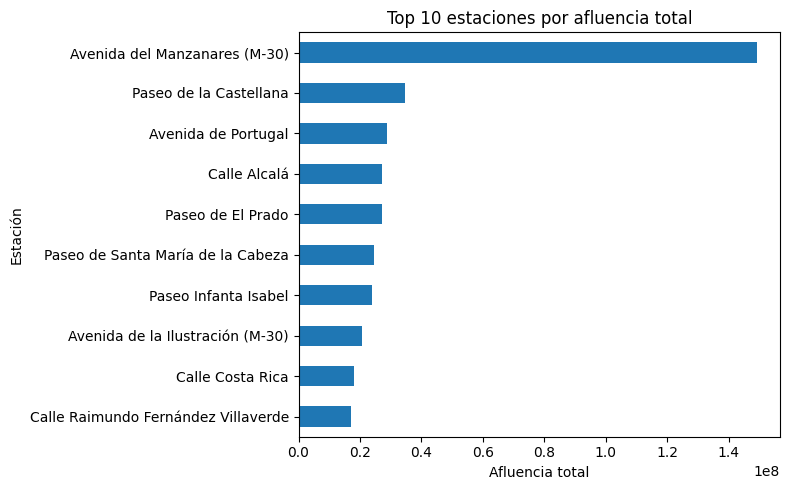

In [24]:
# Totales por estación (Top 10 por afluencia sumada)
df_totales_estacion = (
    df_trafico_reestructrurado
        .groupby('estacion', observed=True)['afluencia']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)
print("Top 10 estaciones por afluencia total:")
print(df_totales_estacion.head(10))

# (Opcional) Gráfico simple de barras Top 10
try:
    top10 = df_totales_estacion.head(10)
    top10.plot(kind='barh', x='estacion', y='afluencia', figsize=(8,5), legend=False, title='Top 10 estaciones por afluencia total')
    plt.xlabel('Afluencia total')
    plt.ylabel('Estación')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
except Exception:
    pass

## Comprobación de cobertura diaria (2022)

Verificamos que haya registros para todos los días del año 2022 en:
- Dataset original (antes de reestructurar): `df_trafico2022` usando la columna `FDIA`.
- Dataset reestructurado: `df_trafico_reestructrurado` usando la columna `Dia`.

Se mostrará cuántos días hay presentes, cuántos faltan y el listado de días faltantes si los hubiera.

In [25]:
# Comprobación de cobertura diaria para 2022 en ambos datasets
import pandas as pd

# Rango completo de días de 2022
rango_2022 = pd.date_range('2022-01-01', '2022-12-31', freq='D')
dias_2022 = set(rango_2022.date)

# Dataset original
fechas_orig = pd.to_datetime(df_trafico2022['FDIA']).dt.date
presentes_orig = set(fechas_orig)
faltantes_orig = sorted(dias_2022 - presentes_orig)

print('ORIGINAL (df_trafico2022 | columna FDIA)')
print(f"- Días distintos presentes: {len(presentes_orig)}")
print(f"- Días faltantes: {len(faltantes_orig)}")
if len(faltantes_orig) > 0:
    print('  Lista de faltantes:')
    print(faltantes_orig)
print(f"- Rango observado: {fechas_orig.min()} a {fechas_orig.max()}\n")

# Dataset reestructurado
fechas_restr = pd.to_datetime(df_trafico_reestructrurado['Dia']).dt.date
presentes_restr = set(fechas_restr)
faltantes_restr = sorted(dias_2022 - presentes_restr)

print('REESTRUCTURADO (df_trafico_reestructrurado | columna Dia)')
print(f"- Días distintos presentes: {len(presentes_restr)}")
print(f"- Días faltantes: {len(faltantes_restr)}")
if len(faltantes_restr) > 0:
    print('  Lista de faltantes:')
    print(faltantes_restr)
print(f"- Rango observado: {fechas_restr.min()} a {fechas_restr.max()}")

ORIGINAL (df_trafico2022 | columna FDIA)
- Días distintos presentes: 354
- Días faltantes: 11
  Lista de faltantes:
[datetime.date(2022, 12, 1), datetime.date(2022, 12, 2), datetime.date(2022, 12, 3), datetime.date(2022, 12, 4), datetime.date(2022, 12, 5), datetime.date(2022, 12, 6), datetime.date(2022, 12, 7), datetime.date(2022, 12, 8), datetime.date(2022, 12, 9), datetime.date(2022, 12, 10), datetime.date(2022, 12, 11)]
- Rango observado: 2022-01-01 a 2022-12-31

REESTRUCTURADO (df_trafico_reestructrurado | columna Dia)
- Días distintos presentes: 354
- Días faltantes: 11
  Lista de faltantes:
[datetime.date(2022, 12, 1), datetime.date(2022, 12, 2), datetime.date(2022, 12, 3), datetime.date(2022, 12, 4), datetime.date(2022, 12, 5), datetime.date(2022, 12, 6), datetime.date(2022, 12, 7), datetime.date(2022, 12, 8), datetime.date(2022, 12, 9), datetime.date(2022, 12, 10), datetime.date(2022, 12, 11)]
- Rango observado: 2022-01-01 a 2022-12-31
